# When an airline melts down, does its stock? ✈️
### Groundings, cancellation collapses, viral PR disasters — and what they actually do to the share price

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Reputational%20shock%3F: Mixed](https://img.shields.io/badge/Reputational%20shock%3F-Mixed-8b949e?style=flat-square)

Southwest strands a million travellers over Christmas. A software bug grounds Delta's entire fleet. United drags a bloodied passenger off a plane on video. Boeing's 737 MAX gets grounded — twice. Every time, the same instinct: *this will hurt the stock — the brand is damaged, customers will flee, and the share price should carry the scar for weeks.*

That's the claim we test on **10 of the most infamous airline and Boeing operational meltdowns since 2016** — measuring the *implicated* company's own stock (not the market), both in the days around the meltdown and over the month that follows.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the airlines-vs-Boeing decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from airline_meltdown import data, strategy as st

EVENTS = data.coverable_events()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, STOCKS = data.load_prices()
    CARS = st.stack_event_cars(EVENTS, SPY, STOCKS)
else:
    SPY = STOCKS = CARS = None
print("real cache present:", HAVE_REAL, "| coverable meltdowns:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events_all': 10, 'n_events': 9, 'cal_lo': '2016-08-08', 'cal_hi': '2024-07-19', 'events': [('2016-08-08', 'DAL', -23.9, -184.9, 938.1, 962.0), ('2017-01-30', 'DAL', -331.1, -491.3, -769.9, -438.8), ('2017-04-10', 'UAL', 69.8, -17.9, 506.4, 436.7), ('2019-03-11', 'BA', -751.0, -1554.9, -2450.4, -1699.4), ('2021-10-11', 'LUV', -280.8, -813.4, -928.4, -647.6), ('2021-11-01', 'AAL', 287.4, 1119.9, -1038.8, -1326.2), ('2022-12-27', 'LUV', -564.8, -944.7, -422.5, 142.3), ('2024-01-08', 'BA', -952.9, -1548.9, -2391.0, -1438.1), ('2024-07-19', 'DAL', 193.9, -12.5, -1038.6, -1232.5)], 'head': {'day0': (-261.5, -1.82, -4.28, 6, 9, 35, 88), 'week': (-494.3, -1.76, -4.59, 8, 9, 56, 98), 'month': (-843.9, -2.24, -2.74, 7, 9, 45, 94), 'drift': (-582.4, -1.88, -2.18, 6, 9, 35, 88)}, 'placebo': {'day0': (-261.5, -0.5, 75.2, 0.002, 5000), 'month': (-843.9, -2.8, 383.2, 0.014, 5000), 'drift': (-582.4, -2.7, 375.3, 0.056, 5000)}, 'split': {'all': (-261.5, -1.82, -843.9, -2.24, 9), 'air': (-92.8, -0.79, -393.4, -1.3, 7), 'boe': (-851.9, -8.44, -2420.7, -81.48, 2)}, 'loo_drop_ba2019': -1.78, 'loo_drop_ba2024': -1.77, 'pre2022_month_t': -1.26, 'post2022_month_t': -2.21, 'timer': {5: (213.4, 197.5, 0.87, 78, -18.2, -0.08), 10: (258.9, 237.0, 1.09, 67, 96.3, 0.37), 21: (176.1, 141.1, 0.44, 56, -25.7, -0.07)}, 'syn_null_mean': -0.08, 'syn_null_sd': 1.05, 'syn_null_fire': 1, 'syn_planted_t': -8.48, 'syn_planted_bps': -283.5, 'fp_spy': '6ce22fa749d2', 'fp_luv': '710a0aa31fcf', 'fp_dal': '24f189e4696e', 'fp_ual': 'd6b73e44a59c', 'fp_aal': '0b16d927b778', 'fp_ba': '4be94ccd2936'}


real cache present: True | coverable meltdowns: 9


## The answer first

| Question | Answer |
|---|---|
| Does the average meltdown stock drop over the next month? | **On paper, yes — -844 bps** (about −8.4%), which even looks statistically real. |
| ...but is that a *reputation* effect? | **No — it's Boeing.** Take out the two Boeing 737-MAX groundings (which ground the actual product line — a real earnings hit, not just bad press) and the drop shrinks to **-393 bps** and stops being significant. |
| Do the pure airline meltdowns (cancellations, IT outages, the United dragging) hurt the stock? | **Not reliably.** Several actually had *positive* one-month returns — the operation gets fixed in days and the market moves on. |
| Could you trade it (short the meltdown)? | **Not really.** It's positive in-sample but rests entirely on those two Boeing events — strip them and it's a coin flip. |

> A tidy story with one real exception baked in: a grounded *product line* genuinely dents the stock; a bad weekend of cancellations mostly doesn't.

## 1 · The claim

> *"An operational meltdown is a reputational catastrophe. Passengers are furious, the story leads every news cycle for a week, regulators open investigations, and the brand takes lasting damage. The stock should drop on the news and keep bleeding as the reputational cost sinks in."*

It's an intuitive, almost obvious idea — and the academic event-study literature on product recalls and corporate crises gives it a real, if modest, prior. The catch that literature also flags: the price reaction concentrates in a **short window**, and it mostly reflects **fundamental** costs (grounded planes, lost bookings, lawsuits), not free-floating "reputation."

## 2 · So what?

If a meltdown reliably dented the stock for a month, that's a tradable, repeatable pattern — short the airline the day the meltdown breaks, cover a few weeks later. And it would be a clean example of markets pricing **soft** damage (brand, goodwill) rather than just hard cash flows.

So we ask: does the implicated stock actually drop, does the drop *stick* for a month, and — crucially — is it about reputation or about real, fundamental damage?

## 3 · How would we even know?

- **The calendar.** **10** famous operational meltdowns 2016-08-08 → 2024-07-19 — Delta's 2016 outage and 2024 CrowdStrike collapse, United's 2017 passenger-dragging, Boeing's 2019 and 2024 MAX groundings, Southwest's 2021 and 2022 cancellation collapses, American's 2021 meltdown, Spirit's 2021 wave. (Spirit's stock is gone — it went bankrupt and delisted — so 9 have price data.)
- **The measurement.** For each one, the *implicated* stock's return around the event **minus what the market did** (so we're not just measuring "stocks went up that month").
- **The luck check.** Hand each event a *random* date instead, 5,000 times — how often does a random calendar produce a drop this big?
- **The tell.** Split airlines vs. Boeing — because a grounded product line is a different animal from a bad weekend of cancellations.

## 4 · The teardown — let's actually look

**First, the headline.** Average one-month abnormal return of the implicated stock across all 9 meltdowns — and where a *random* calendar of the same 9 stocks would land.

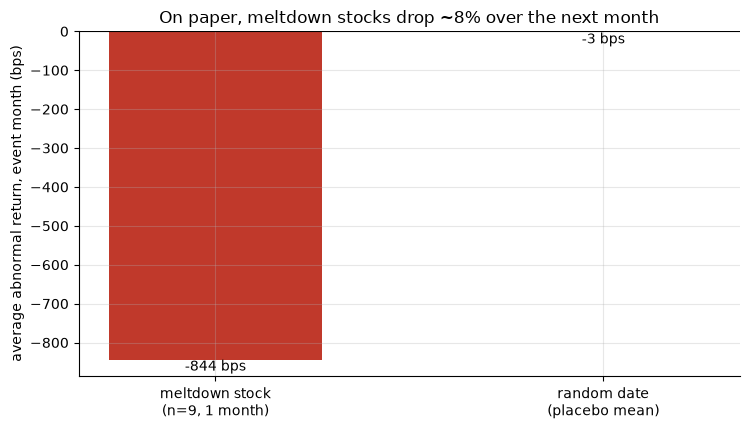

meltdown month -844 bps vs random -3 bps


In [2]:
if HAVE_REAL:
    month_bps = st.car_stats(CARS, 'month')['mean_bps']
else:
    month_bps = R['head']['month'][0]
pmean = R['placebo']['month'][1]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['meltdown stock\n(n=9, 1 month)', 'random date\n(placebo mean)'],
       [month_bps, pmean], color=[RED, GREY], width=.55)
for i, v in enumerate([month_bps, pmean]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average abnormal return, event month (bps)')
ax.set_title('On paper, meltdown stocks drop ~8% over the next month')
plt.tight_layout(); plt.show()
print(f'meltdown month {month_bps:+.0f} bps vs random {pmean:+.0f} bps')

That looks like a real effect: **-844 bps** over the month, versus roughly zero for a random date, and a random calendar beats it only about **1.4%** of the time. But before we celebrate — *which* meltdowns are doing the work?

**The tell: split the two Boeing groundings out from the airline meltdowns.**

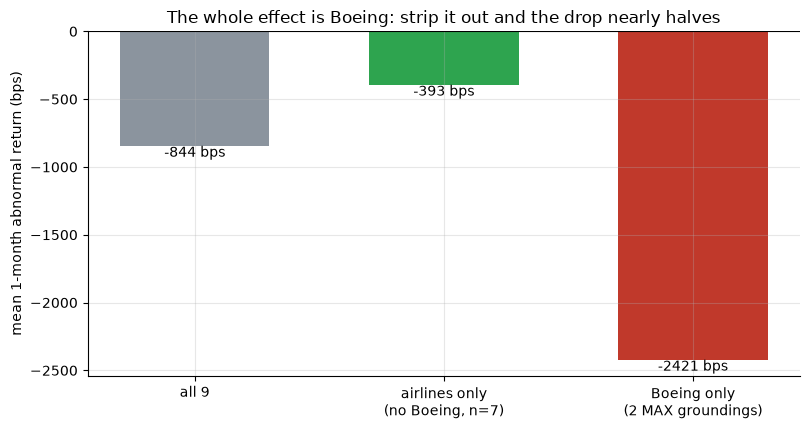

all -844 | airlines-only -393 | Boeing-only -2421 bps


In [3]:
if HAVE_REAL:
    allm = st.car_stats(CARS, 'month')['mean_bps']
    airm = st.car_stats(CARS[CARS['ticker'] != 'BA'], 'month')['mean_bps']
    boem = st.car_stats(CARS[CARS['ticker'] == 'BA'], 'month')['mean_bps']
else:
    allm, airm, boem = R['split']['all'][2], R['split']['air'][2], R['split']['boe'][2]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['all 9', 'airlines only\n(no Boeing, n=7)', 'Boeing only\n(2 MAX groundings)'],
       [allm, airm, boem], color=[GREY, GREEN, RED], width=.6)
for i, v in enumerate([allm, airm, boem]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 1-month abnormal return (bps)')
ax.set_title('The whole effect is Boeing: strip it out and the drop nearly halves')
plt.tight_layout(); plt.show()
print(f'all {allm:+.0f} | airlines-only {airm:+.0f} | Boeing-only {boem:+.0f} bps')

There it is. The two **Boeing MAX groundings** average a brutal **-2421 bps** over the month — because grounding the MAX halts deliveries and torches earnings, a *fundamental* hit. The seven pure airline meltdowns average only **-393 bps**, and that's no longer statistically distinguishable from zero. A cancellation collapse is a miserable week for travellers — but the airline restores its schedule in days, and the stock mostly shrugs.

**Look at the individual events** to see how mixed the airline side is:

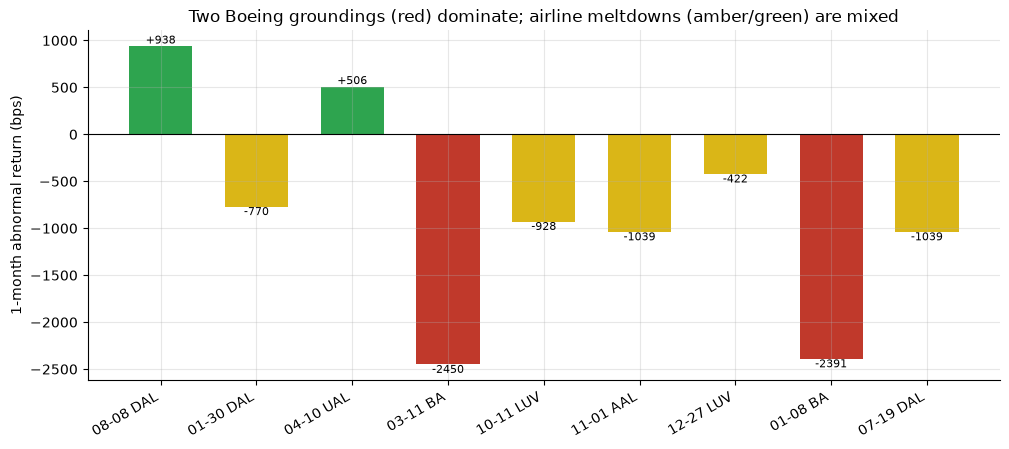

Boeing = ['2019-03-11', '2024-01-08'] | positive-month meltdowns: ['2016-08-08', '2017-04-10']


In [4]:
rows = R['events']
labels = [f"{d[5:]} {t}" for (d, t, *_ ) in rows]
vals = [e[4] for e in rows]           # month CAR bps
cols = [RED if e[1] == 'BA' else (GREEN if e[4] > 0 else AMBER) for e in rows]
fig, ax = plt.subplots(figsize=(10.2, 4.6))
ax.bar(labels, vals, color=cols, width=.66)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.0f}', (i, v), ha='center', va='top' if v < 0 else 'bottom', fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('1-month abnormal return (bps)')
ax.set_title('Two Boeing groundings (red) dominate; airline meltdowns (amber/green) are mixed')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print('Boeing =', [e[0] for e in rows if e[1]=='BA'], '| positive-month meltdowns:',
      [e[0] for e in rows if e[1]!='BA' and e[4] > 0])

Delta's 2016 outage (**+938 bps**) and United's 2017 dragging crisis (**+506 bps**) actually had *positive* one-month abnormal returns — the stocks were fine a month later. The two red Boeing bars are in a different league entirely, and they're the reason the aggregate looks significant.

## 5 · The verdict

- **Signal — Weak.** The 9-event average one-month drop (**-844 bps**, placebo *p* = 0.014) looks real but isn't robust: strip the two Boeing groundings — fundamental product-line shocks, not reputation — and it fades to **-393 bps** and loses significance.
- **Tradability — Fragile.** Shorting the meltdown works in-sample but rests on two events; airlines-only it's roughly a coin flip.
- **Reputational shock vs quick fade? — Mixed.** A grounded product line dents the stock (Boeing). A bad weekend of cancellations mostly fades.

## 6 · Going further 🚪

- **N is the honest limit.** Nine coverable meltdowns is a tiny sample; a small reputational effect could easily hide in it. The clean finding isn't "reputation never matters" — it's "in this tradable sample, the only durable stock damage came from a *fundamental* grounding, not from bad press."
- **Where a real version might live:** a much larger register of smaller operational disruptions, forward-booking or app-store-rating data as a reputation proxy, or the credit/CDS market rather than equity.
- **Sibling studies:** [707-plane-crash-effect](../../707-plane-crash-effect/) (fatal crashes → broad-market mood), [554-airline-bookings](../../554-airline-bookings/) (an alt-data demand signal) and [313-geopolitical-shock](../../313-geopolitical-shock/) (wars/attacks → market-wide) — related triggers, different targets.

*Think a bigger meltdown register or a reputation proxy would find the effect the equity tape misses? Show it — out-of-sample, after costs — then we'll talk.*